In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [3]:
import librosa
audio = librosa.load("dataset/snare/Snare Sample 1.wav")
print(audio[0])

[-1.8773079e-03 -3.0852854e-04 -8.7781578e-02 ... -1.4649093e-05
 -3.1364194e-05 -5.4585773e-05]


[-5.14334473e+02  5.88325348e+01  1.21119175e+01  1.44286156e+01
 -2.74993682e+00 -9.74721014e-02 -7.55179453e+00 -6.98553133e+00
 -9.57705402e+00 -6.95634651e+00 -5.09109163e+00  1.95081723e+00
  5.70243692e+00]


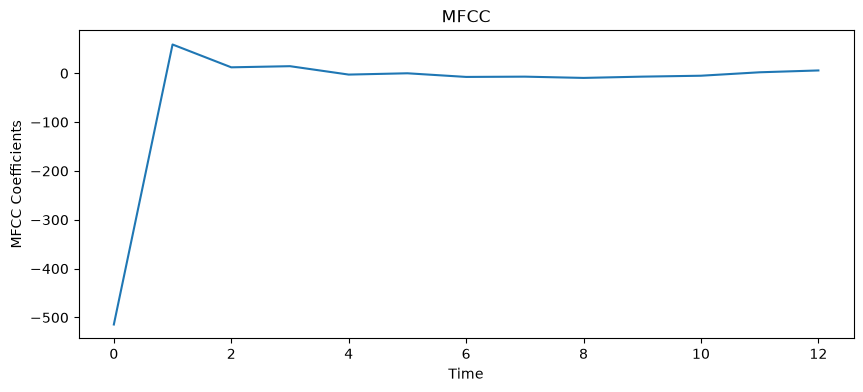

In [4]:
audio_mfcc = librosa.feature.mfcc(y=audio[0], sr=22050, n_mfcc=13)
mfcc_mean = audio_mfcc.T.mean(axis=0)
print(mfcc_mean)
plt.figure(figsize=(10, 4))
plt.plot(mfcc_mean)
plt.xlabel('Time')
plt.ylabel('MFCC Coefficients') 
 
plt.title('MFCC')
plt.show()

In [5]:
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path)
    audio_mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = audio_mfcc.T.mean(axis=0)
    return mfcc_mean

In [6]:
import os
x = []
y = []


for file in os.listdir("D:\\drumist\\dataset\\kick"):
    if file.endswith(".wav"):
        file_path = os.path.join("D:\\drumist\\dataset\\kick", file)
        mfcc_features = extract_mfcc(file_path)
        x.append(mfcc_features)
        y.append(0)  # Assuming 0 for kick drum samples

for file in os.listdir("D:\\drumist\\dataset\\snare"):
    if file.endswith(".wav"):
        file_path = os.path.join("D:\\drumist\\dataset\\snare", file)
        mfcc_features = extract_mfcc(file_path)
        x.append(mfcc_features)
        y.append(1)  # Assuming 1 for snare drum samples

for file in os.listdir("D:\\drumist\\dataset\\overheads"):
    if file.endswith(".wav"):
        file_path = os.path.join("D:\\drumist\\dataset\\overheads", file)
        mfcc_features = extract_mfcc(file_path)
        x.append(mfcc_features)
        y.append(2)  # Assuming 2 for overhead drum samples

for file in os.listdir("D:\\drumist\\dataset\\toms"):
    if file.endswith(".wav"):
        file_path = os.path.join("D:\\drumist\\dataset\\toms", file)
        mfcc_features = extract_mfcc(file_path)
        x.append(mfcc_features)
        y.append(3)  # Assuming 3 for toms drum samples


print(x,y)

[array([-494.09744 ,   34.417984,   20.870354,   28.17016 ,   22.621798,
         20.32468 ,   21.064865,   19.298735,   15.822322,   14.147534,
         13.088856,   11.514573,    9.56167 ], dtype=float32), array([-499.41556  ,   31.287727 ,   14.974615 ,   22.5907   ,
         16.18649  ,   14.632249 ,   15.80211  ,   13.6553335,
         12.243935 ,   11.9021225,    8.790745 ,    7.1199446,
          6.1807127], dtype=float32), array([-522.3021   ,   30.121553 ,   16.342861 ,   22.011864 ,
         13.94357  ,   15.210235 ,   15.124574 ,   11.965439 ,
         10.354646 ,    7.907116 ,    5.1113744,    4.5847964,
          3.4351344], dtype=float32), array([-504.23602 ,   33.73533 ,   22.219172,   28.828077,   21.592583,
         20.703268,   20.876945,   17.362774,   13.827784,   13.56899 ,
         11.807359,    9.020124,    7.862929], dtype=float32), array([-500.3421  ,   32.89993 ,   19.643908,   26.688341,   20.76923 ,
         21.00752 ,   18.681503,   17.322708,   15.727416, 

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
x = np.reshape(x,-1,1)
y = np.reshape(y,-1,1)
x_test,y_test,x_train,y_train = train_test_split(x,y,test_size=0.2,random_state=42)


drummer = GradientBoostingClassifier(loss='log_loss',n_estimators=100,learning_rate=1.0,)
drummer.fit(x_train,y_train)




KeyboardInterrupt

